# AE reconstruction — optimised contour

Section 3.6 (*Optimal Laplace contour choice*), reconstruction stage, and Appendix D. Covers the `_ll` (LLAE, learnable contour) and `_ol` (SLAE, offline contour) checkpoints.


In [1]:
import sys, os
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

# Always run from repo root (InferencePipelineAE uses paths relative to repo root).
# The notebook directory must enter sys.path before the chdir: nbclient puts only
# '' there, resolved against the current working directory, so after the chdir
# `import figstyle` would no longer resolve.
_NB_DIR = os.path.abspath('notebooks' if os.path.basename(os.getcwd()) != 'notebooks' else '.')
if _NB_DIR not in sys.path:
    sys.path.insert(0, _NB_DIR)

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

sys.path.insert(0, 'src')

from omegaconf import open_dict

import glob
import re
import gc
import numpy as np
import torch
import torch.nn.functional as F_nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from laplace_surrogate.inference.pipeline_ae import InferencePipelineAE


/users/eleves-b/2023/keyvan.attarian/diffusion_ae/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Article figure style; `run` prefixes the output filenames.
import figstyle
figstyle.setup(run='optae')       # titles=True pour garder les suptitle en interactif


figstyle: style=paper.mplstyle  run=optae  titles=suppressed  ->  /users/eleves-b/2023/keyvan.attarian/diffusion_ae/article/images


## 1. Dataset loading and normalisation

In [3]:
DATA_PATH  = 'dataset/ch4_rotated.npy'
SPLIT_PATH = 'dataset/split.npz'
CKPT_DIR   = 'checkpoints'
CACHE_DIR  = 'notebooks/cache'
N          = 128
DT         = 1.0

# Tikhonov regularisation used to evaluate the reconstruction, aligned on
# configs/training/surrogate_slae.yaml so that both stages invert in the same regime.
ALPHA_T_INV = 7e-3
LAM_INV     = 3e-5


os.makedirs(CACHE_DIR, exist_ok=True)

U_raw = np.load(DATA_PATH, mmap_mode='r')          # (ns, Nt, H, W)
ns, Nt_full, H, W = U_raw.shape
print(f'Dataset: {ns} sims, Nt={Nt_full}, {H}×{W}')

split     = np.load(SPLIT_PATH)
test_idx  = split['test_idx'].tolist()
train_idx = [i for i in range(ns) if i not in set(test_idx)]
print(f'Train: {len(train_idx)}  Test: {len(test_idx)}')


Dataset: 8100 sims, Nt=150, 128×128


Train: 6480  Test: 1620


In [4]:
def load_u(idx: int) -> np.ndarray:
    """Load and resize to (Nt, N, N) float32."""
    u = U_raw[idx].astype(np.float32)
    if u.shape[-1] != N:
        u_t = torch.from_numpy(u).unsqueeze(1)
        u_t = F_nn.interpolate(u_t, size=(N, N), mode='bilinear', align_corners=False)
        u   = u_t.squeeze(1).numpy()
    return u

## 2. Evaluation functions

In [5]:
def eval_ae(ckpt_path: str, idx_list: list, device='cpu', batch_size: int = 8) -> np.ndarray:
    """
    Reconstruit U via InferencePipelineAE et calcule le L2rel (%) sur le champ physique.
    Supporte LLAE et SLAE.
    """
    pipe = InferencePipelineAE.from_checkpoint(ckpt_path, device=device)
    name = os.path.basename(ckpt_path)

    # Phase 1 of SLAE never inverts, so the AE checkpoint carries no regularisation
    # and the pipeline would fall back on a near-singular default. Use the values the
    # surrogate is trained with. The _ol contours keep their own, optimised jointly
    # with the poles.
    if not getattr(pipe.cfg.model, 'optimal_laplace', False):
        with open_dict(pipe.cfg):
            pipe.cfg.model.alpha_t = ALPHA_T_INV
            pipe.cfg.model.lam     = LAM_INV

    l2rel_list = []
    for start in tqdm(range(0, len(idx_list), batch_size), desc=name, leave=False):
        batch_idx = idx_list[start:start + batch_size]
        U_batch   = np.stack([load_u(i) for i in batch_idx])   # (B, Nt, N, N)
        U_rec     = pipe.reconstruct(U_batch)                   # (B, Nt, N, N)

        for j in range(len(batch_idx)):
            denom = np.linalg.norm(U_batch[j])
            if denom >= 1e-12:
                l2rel_list.append(np.linalg.norm(U_rec[j] - U_batch[j]) / denom * 100.0)

        if device == 'cuda':
            torch.cuda.empty_cache()

    pipe.model.cpu()
    del pipe
    if device == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()
    return np.array(l2rel_list)

## 3. Evaluation of all checkpoints

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

ckpt_paths = sorted([
    p for p in glob.glob(os.path.join(CKPT_DIR, '*.ckpt'))
    if ((os.path.basename(p).startswith('llae_') or os.path.basename(p).startswith('slae_')) 
    and ( os.path.basename(p).find('_ll') != -1 or os.path.basename(p).find('_ol') != -1 ))
])
print(f'{len(ckpt_paths)} AE checkpoints found:')
for p in ckpt_paths:
    print(' ', os.path.basename(p))

Device: cuda
6 AE checkpoints found:
  llae_ld64_K16_g0.0_ll.ckpt
  llae_ld64_K32_g0.0_ll.ckpt
  llae_ld64_K8_g0.0_ll.ckpt
  slae_ld64_K16_g0.0_ol.ckpt
  slae_ld64_K32_g0.0_ol.ckpt
  slae_ld64_K8_g0.0_ol.ckpt


In [7]:
def _cache_path(name: str) -> str:
    return os.path.join(CACHE_DIR, f'{name}.npz')

def _cache_valid(cache_file: str, ckpt_path: str) -> bool:
    if not os.path.exists(cache_file):
        return False
    data = np.load(cache_file, allow_pickle=True)
    return float(data['ckpt_mtime']) == os.path.getmtime(ckpt_path)

def _save_cache(name: str, ckpt_path: str, l2rel: np.ndarray):
    np.savez(
        _cache_path(name),
        l2rel      = l2rel,
        ckpt_mtime = np.float64(os.path.getmtime(ckpt_path)),
    )

def _load_cache(name: str) -> np.ndarray:
    return np.load(_cache_path(name))['l2rel']


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}\n')

results = {}   # name → np.array L2rel (%)

for ckpt_path in ckpt_paths:
    name       = os.path.splitext(os.path.basename(ckpt_path))[0]
    model_type = 'llae' if name.startswith('llae') else 'slae'
    cache_file = _cache_path(name)

    if _cache_valid(cache_file, ckpt_path):
        l2 = _load_cache(name)
        print(f'[cache]   {name}')
    else:
        print(f'[compute] {name}  [{model_type}]')
        try:
            l2 = eval_ae(ckpt_path, test_idx, device=device)
            _save_cache(name, ckpt_path, l2)
        except Exception as e:
            print(f'   ERROR: {e}')
            continue

    results[name] = l2
    print(f'   median={np.median(l2):.2f}%  mean={np.mean(l2):.2f}%  p90={np.percentile(l2,90):.2f}%  n={len(l2)}')

print('\nDone.')

Device: cuda

[cache]   llae_ld64_K16_g0.0_ll
   median=2.68%  mean=2.89%  p90=4.16%  n=1620
[cache]   llae_ld64_K32_g0.0_ll
   median=2.60%  mean=2.82%  p90=4.02%  n=1620
[cache]   llae_ld64_K8_g0.0_ll
   median=2.89%  mean=3.15%  p90=4.51%  n=1620
[cache]   slae_ld64_K16_g0.0_ol
   median=16.05%  mean=18.25%  p90=27.61%  n=1620
[cache]   slae_ld64_K32_g0.0_ol
   median=8.53%  mean=9.73%  p90=14.88%  n=1620
[cache]   slae_ld64_K8_g0.0_ol
   median=12.92%  mean=14.51%  p90=21.77%  n=1620

Done.


In [8]:
import re
from collections import defaultdict
from matplotlib.lines import Line2D

_CKPT_PAT = re.compile(r'^(slae|llae)_ld(\d+)_K(\d+)_g([0-9.]+)')

def _pretty_name(name: str) -> str:
    m = _CKPT_PAT.match(name)
    if not m:
        return name
    model = m.group(1).upper()
    ld    = m.group(2)
    K     = m.group(3)
    g     = float(m.group(4))
    g_str = str(int(g)) if g == int(g) else str(g).rstrip('0')
    return f'{model}  d={ld}, K={K}, γ={g_str}'

colors = figstyle.PALETTE                # cles 'slae' / 'llae' — voir notebooks/figstyle.py

pat = re.compile(r'^(?P<ae>llae|slae)_ld(?P<ld>\d+)_K(?P<K>\d+)_g(?P<g>[0-9.]+)(?P<suffix>.*)$')

def _fmt_label(v):
    if isinstance(v, float) and v == int(v):
        return str(int(v))
    return str(v)

# Build rows for ablation plots
ae_rows = []
for name in results:
    m = pat.match(name)
    if not m:
        continue
    ae_rows.append({
        'name'  : name,
        'ae'    : m.group('ae'),
        'ld'    : int(m.group('ld')),
        'K'     : int(m.group('K')),
        'gamma' : float(m.group('g')),
        'suffix': m.group('suffix') or '',
    })

def _select_rows(ae_type, var_name, fixed):
    rows = [r for r in ae_rows
            if r['ae'] == ae_type and all(r[k] == v for k, v in fixed.items())]
    return sorted(rows, key=lambda r: r[var_name])

def _plot_family(ax, rows, var_name, xlabel, title):
    if not rows:
        ax.set_title(f"{title}\n(no matching checkpoints)")
        ax.axis('off')
        return

    groups = defaultdict(list)
    for r in rows:
        groups[r[var_name]].extend(results[r['name']].tolist())

    xs_vals   = sorted(groups.keys())
    datasets  = [groups[v] for v in xs_vals]
    positions = list(range(len(xs_vals)))

    parts = ax.violinplot(datasets, positions=positions,
                          widths=0.65, showmedians=True, showmeans=True, showextrema=True)
    for pc in parts['bodies']:
        pc.set_alpha(0.55)
    parts['cmedians'].set_color('black');   parts['cmedians'].set_linewidth(2.2)
    parts['cmeans'].set_color('orange');    parts['cmeans'].set_linewidth(1.8)
    parts['cmeans'].set_linestyle('--')
    parts['cmaxes'].set_linewidth(0.8)
    parts['cmins'].set_linewidth(0.8)
    parts['cbars'].set_linewidth(0.8)

    ax.set_xticks(positions)
    ax.set_xticklabels([_fmt_label(v) for v in xs_vals], fontsize=9)
    ax.set_xlim(-0.7, len(xs_vals) - 0.3)
    ax.legend(handles=[
        Line2D([0], [0], color='black',  linewidth=2.2,              label='median'),
        Line2D([0], [0], color='orange', linewidth=1.8, linestyle='--', label='mean'),
    ], fontsize=8)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('L2rel (%)')
    ax.grid(alpha=0.3, axis='y')


## 4. Laplace poles $s_k$ and inversion regularization

Read directly from the raw checkpoints, one panel per checkpoint:

- **LLAE** — the poles live in the model (`model.laplace.*` in the `state_dict`):
  current poles, their init buffers, and $\alpha_t$ / $\lambda$ taken from
  `log_alpha_t` / `log_lam` when `learnable_laplace=True`, from the frozen buffers otherwise.
- **SLAE** — the transform is applied in the data domain: the poles are the checkpoint's
  `s_list` (init reference: `gamma_init` + truncated FFT contour), and $(\alpha_t, \lambda)$
  come from the offline optimisation file when `optimal_laplace=True`
  (same logic as `InferencePipelineAE._reconstruct_slae`).


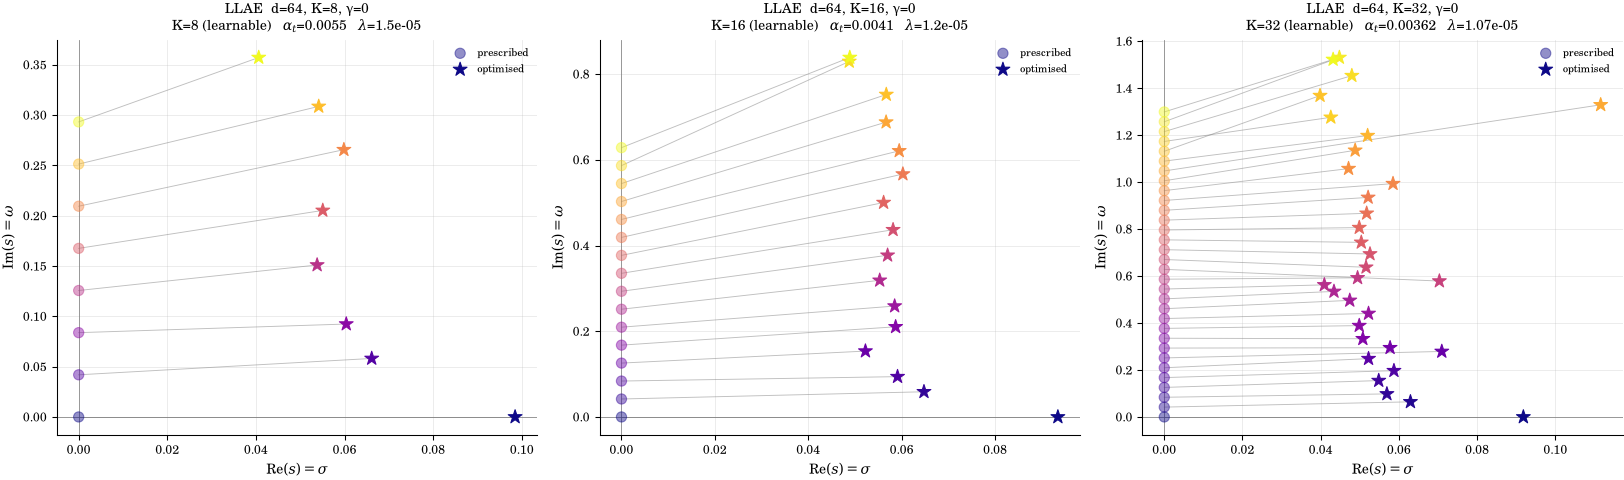

  ↳ article/images/optae_contour_poles_llae.pdf


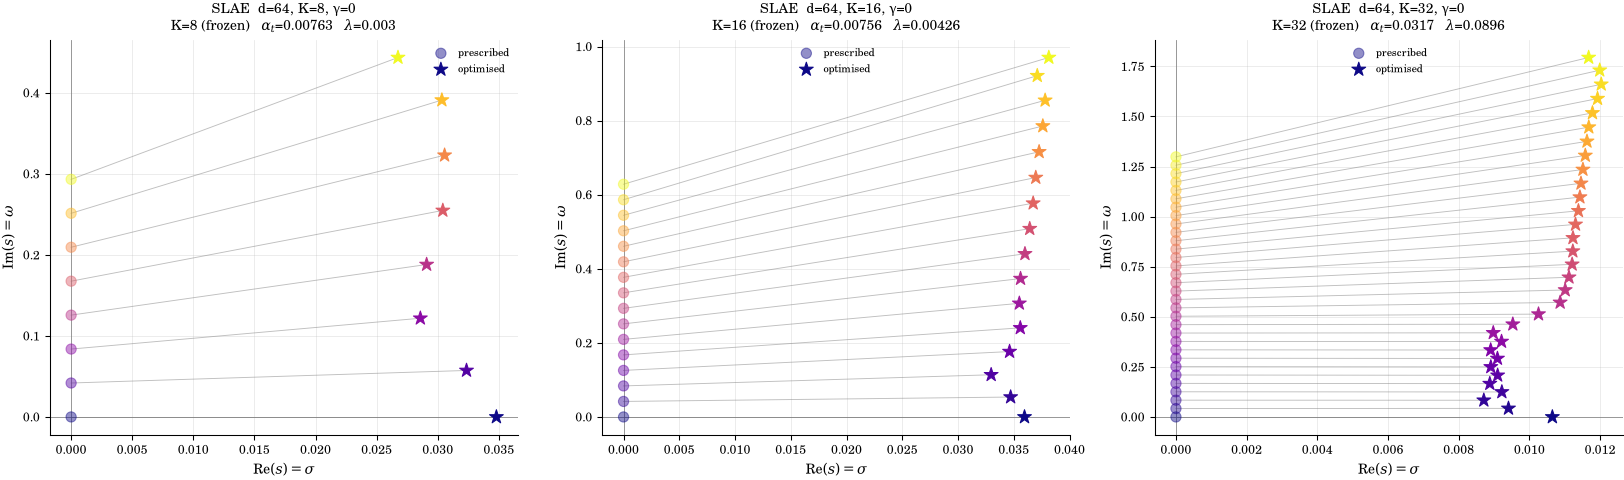

  ↳ article/images/optae_contour_poles_slae.pdf


In [9]:
# ── Laplace poles s_k + regularization used by the AE checkpoints ────────
pole_info = {}   # name → dict

for ckpt_path in ckpt_paths:
    name  = os.path.splitext(os.path.basename(ckpt_path))[0]
    raw   = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    cfg_m = raw['hyper_parameters']['cfg'].model

    if cfg_m.name == 'llae':
        sd        = raw['state_dict']
        learnable = bool(getattr(cfg_m, 'learnable_laplace', False))
        s_cur  = (sd['model.laplace.s_re'] + 1j * sd['model.laplace.s_im']).numpy()
        s_init = (sd['model.laplace._s_init_re'] + 1j * sd['model.laplace._s_init_im']).numpy()
        if learnable:
            alpha_t = float(sd['model.laplace.log_alpha_t'].exp())
            lam     = float(sd['model.laplace.log_lam'].exp())
        else:
            alpha_t = float(sd['model.laplace._alpha_t_fixed'])
            lam     = float(sd['model.laplace._lam_fixed'])
    else:  # slae
        learnable = False
        K      = int(cfg_m.K)
        dt     = float(raw.get('dt', DT))
        s_cur  = raw['s_list'].astype(np.complex128)
        s_init = cfg_m.gamma_init + 1j * 2 * np.pi * np.fft.rfftfreq(Nt_full, d=dt)[:K]
        alpha_t = float(getattr(cfg_m, 'alpha_t', 0.0))
        lam     = float(getattr(cfg_m, 'lam',     1e-6))
        if getattr(cfg_m, 'optimal_laplace', False):
            opt_path = getattr(cfg_m, 'optimal_laplace_path', None)
            if opt_path and os.path.exists(opt_path):
                opt = torch.load(opt_path, map_location='cpu', weights_only=False)
                alpha_t, lam = float(opt['alpha_t']), float(opt['lam'])
            else:
                alpha_t = lam = None   # optimisation file missing locally

    pole_info[name] = dict(ae=str(cfg_m.name), s_cur=np.asarray(s_cur),
                           s_init=np.asarray(s_init), alpha_t=alpha_t, lam=lam,
                           learnable=learnable)
    del raw
gc.collect()

for family in ('llae', 'slae'):
    fam_names = sorted(
        [n for n in pole_info if pole_info[n]['ae'] == family],
        key=lambda n: (len(pole_info[n]['s_cur']), n),
    )
    if not fam_names:
        print(f'No {family} checkpoint found.')
        continue

    ncols = min(4, len(fam_names))
    nrows = int(np.ceil(len(fam_names) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.0 * ncols, 4.6 * nrows), squeeze=False)
    for ax in axes.flat[len(fam_names):]:
        ax.axis('off')

    for ax, n in zip(axes.flat, fam_names):
        info = pole_info[n]
        s_cur, s_ini = info['s_cur'], info['s_init']
        K = len(s_cur)
        c = np.arange(K)
        for a, b in zip(s_ini, s_cur):
            ax.plot([a.real, b.real], [a.imag, b.imag], color='gray', lw=0.6, alpha=0.5, zorder=1)
        ax.scatter(s_ini.real, s_ini.imag, c=c, cmap='plasma', s=45, marker='o',
                   alpha=0.45, zorder=3, label='prescribed')
        ax.scatter(s_cur.real, s_cur.imag, c=c, cmap='plasma', s=90, marker='*',
                   zorder=4, label='optimised')
        ax.axvline(0, color='gray', lw=0.5)
        ax.axhline(0, color='gray', lw=0.5)
        ax.set_xlabel(r'Re$(s) = \sigma$')
        ax.set_ylabel(r'Im$(s) = \omega$')
        tag = 'learnable' if info['learnable'] else 'frozen'
        if info['alpha_t'] is None:
            reg = r'$\alpha_t$, $\lambda$: n/a (opti file missing)'
        else:
            reg = rf'$\alpha_t$={info["alpha_t"]:.3g}   $\lambda$={info["lam"]:.3g}'
        ax.set_title(_pretty_name(n) + '\n' + rf'K={K} ({tag})   ' + reg, fontsize=9)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=7)

    fig.suptitle(f'{family.upper()} — Laplace poles $s_k$ and inversion regularization',
                 fontweight='bold')
    fig.tight_layout()
    plt.show()
    figstyle.save("contour_poles_" + str(family).replace("Model", "").lower())


## 5. Histograms per checkpoint

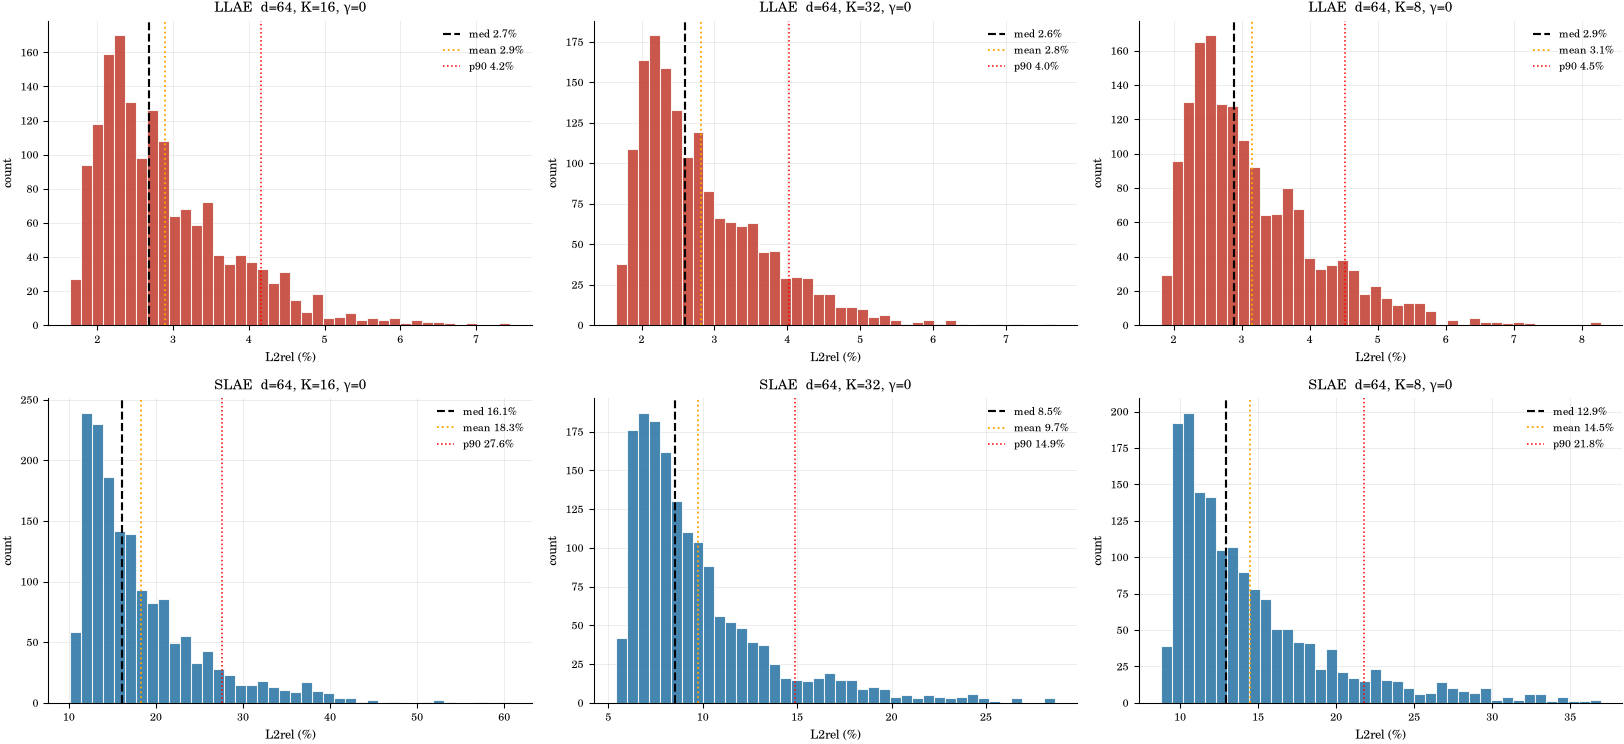

  ↳ article/images/optae_hist_grid.pdf


PosixPath('/users/eleves-b/2023/keyvan.attarian/diffusion_ae/article/images/optae_hist_grid.pdf')

In [10]:
names  = list(results.keys())
n_ckpt = len(names)
ncols  = 3
nrows  = (n_ckpt + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = axes.flatten()

colors = figstyle.PALETTE                # cles 'slae' / 'llae' — voir notebooks/figstyle.py

for ax, name in zip(axes, names):
    l2      = results[name]
    mtype   = 'llae' if name.startswith('llae') else 'slae'
    median  = np.median(l2)
    mean    = np.mean(l2)
    p90     = np.percentile(l2, 90)

    ax.hist(l2, bins=40, color=colors[mtype], edgecolor='white', alpha=0.85)
    ax.axvline(median, color='black',  linestyle='--', linewidth=1.4, label=f'med {median:.1f}%')
    ax.axvline(mean,   color='orange', linestyle=':',  linewidth=1.2, label=f'mean {mean:.1f}%')
    ax.axvline(p90,    color='red',    linestyle=':',  linewidth=1.0, label=f'p90 {p90:.1f}%')
    ax.set_title(_pretty_name(name), fontsize=9)
    ax.set_xlabel('L2rel (%)', fontsize=8)
    ax.set_ylabel('count', fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

for ax in axes[n_ckpt:]:
    ax.set_visible(False)

fig.suptitle('L2rel on physical field U — AE reconstruction (test set)', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()
figstyle.save("hist_grid")


## 6. Median comparison

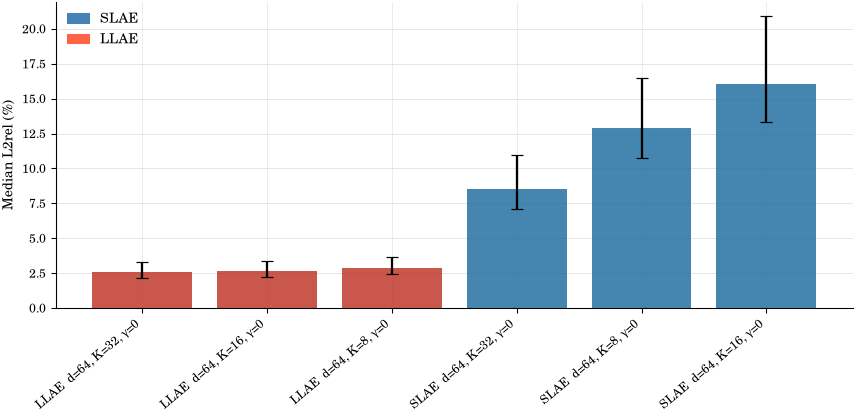

  ↳ article/images/optae_bar_all.pdf


PosixPath('/users/eleves-b/2023/keyvan.attarian/diffusion_ae/article/images/optae_bar_all.pdf')

In [11]:
medians = {n: float(np.median(v)) for n, v in results.items()}
p25     = {n: float(np.percentile(v, 25)) for n, v in results.items()}
p75     = {n: float(np.percentile(v, 75)) for n, v in results.items()}

sorted_names = sorted(medians, key=lambda n: medians[n])
bar_colors   = [colors['llae' if n.startswith('llae') else 'slae'] for n in sorted_names]

fig, ax = plt.subplots(figsize=(max(8, n_ckpt * 0.9), 4))
x = np.arange(len(sorted_names))

bars = ax.bar(x, [medians[n] for n in sorted_names], color=bar_colors, alpha=0.85, zorder=2)

# IQR error bars
yerr_low  = [medians[n] - p25[n] for n in sorted_names]
yerr_high = [p75[n] - medians[n] for n in sorted_names]
ax.errorbar(x, [medians[n] for n in sorted_names],
            yerr=[yerr_low, yerr_high],
            fmt='none', color='black', capsize=4, linewidth=1.5, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels([_pretty_name(n) for n in sorted_names], rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Median L2rel (%)')
ax.grid(axis='y', alpha=0.4, zorder=0)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='steelblue', label='SLAE'),
    Patch(color='tomato',    label='LLAE'),
], fontsize=9)

fig.tight_layout()
plt.show()
figstyle.save("bar_all")


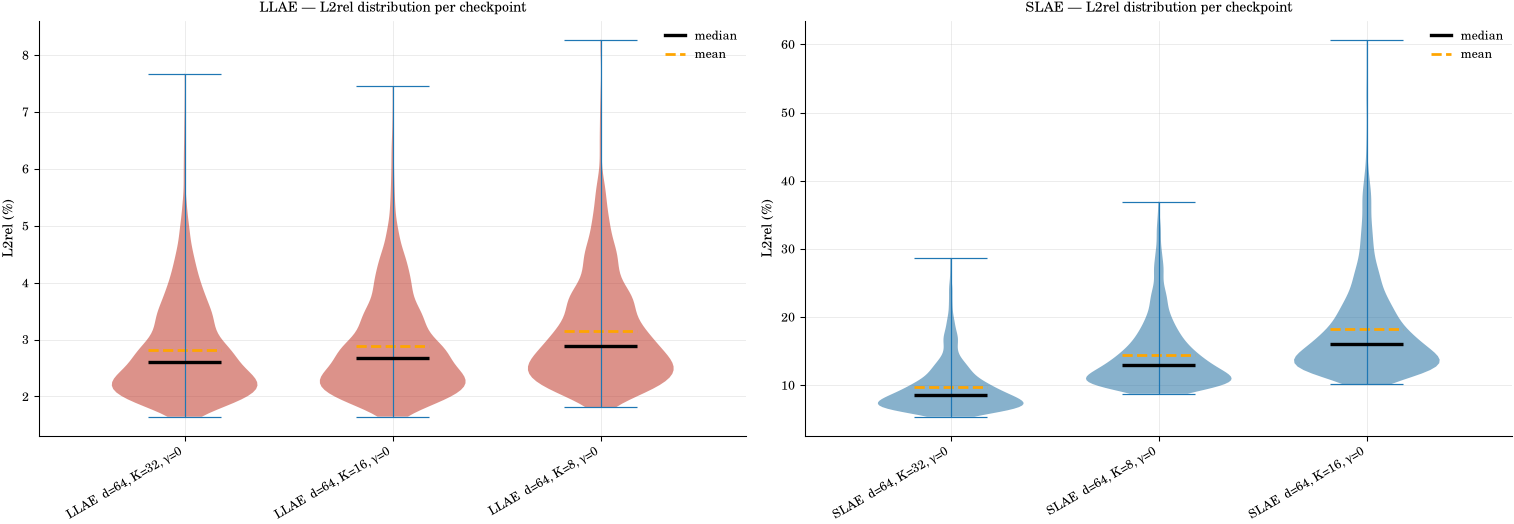

  ↳ article/images/optae_violins_all.pdf


PosixPath('/users/eleves-b/2023/keyvan.attarian/diffusion_ae/article/images/optae_violins_all.pdf')

In [12]:
# One violin per family: full error distribution for each checkpoint.
from matplotlib.lines import Line2D

def _violin_family(ax, family, title):
    fam_names = sorted(
        [n for n in results if n.startswith(family)],
        key=lambda n: np.median(results[n]),
    )
    if not fam_names:
        ax.set_title(f'{title}\n(no matching checkpoints)')
        ax.axis('off')
        return

    datasets  = [results[n] for n in fam_names]
    positions = list(range(len(fam_names)))

    parts = ax.violinplot(datasets, positions=positions,
                          widths=0.7, showmedians=True, showmeans=True, showextrema=True)
    for pc in parts['bodies']:
        pc.set_facecolor(colors[family])
        pc.set_alpha(0.55)
    parts['cmedians'].set_color('black');   parts['cmedians'].set_linewidth(2.2)
    parts['cmeans'].set_color('orange');    parts['cmeans'].set_linewidth(1.8)
    parts['cmeans'].set_linestyle('--')
    parts['cmaxes'].set_linewidth(0.8)
    parts['cmins'].set_linewidth(0.8)
    parts['cbars'].set_linewidth(0.8)

    ax.set_xticks(positions)
    ax.set_xticklabels([_pretty_name(n) for n in fam_names], rotation=30, ha='right', fontsize=8)
    ax.set_xlim(-0.7, len(fam_names) - 0.3)
    ax.set_ylabel('L2rel (%)')
    ax.set_title(title)
    ax.grid(alpha=0.3, axis='y')
    ax.legend(handles=[
        Line2D([0], [0], color='black',  linewidth=2.2,                    label='median'),
        Line2D([0], [0], color='orange', linewidth=1.8, linestyle='--',    label='mean'),
    ], fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
_violin_family(axes[0], 'llae', 'LLAE — L2rel distribution per checkpoint')
_violin_family(axes[1], 'slae', 'SLAE — L2rel distribution per checkpoint')

fig.suptitle('Checkpoint comparison — L2rel distributions (test set)', fontweight='bold')
fig.tight_layout()
plt.show()
figstyle.save("violins_all")


## 7. Summary 

In [13]:
print(f"{'Checkpoint':<40}  {'type':^5}  {'median':>8}  {'mean':>8}  {'p90':>8}  {'n':>5}")
print('-' * 82)
for n in sorted(results, key=lambda n: np.median(results[n])):
    l2    = results[n]
    mtype = 'llae' if n.startswith('llae') else 'slae'
    print(f'{n:<40}  {mtype:^5}  {np.median(l2):>7.2f}%  {np.mean(l2):>7.2f}%  {np.percentile(l2,90):>7.2f}%  {len(l2):>5}')

Checkpoint                                type     median      mean       p90      n
----------------------------------------------------------------------------------
llae_ld64_K32_g0.0_ll                     llae      2.60%     2.82%     4.02%   1620
llae_ld64_K16_g0.0_ll                     llae      2.68%     2.89%     4.16%   1620
llae_ld64_K8_g0.0_ll                      llae      2.89%     3.15%     4.51%   1620
slae_ld64_K32_g0.0_ol                     slae      8.53%     9.73%    14.88%   1620
slae_ld64_K8_g0.0_ol                      slae     12.92%    14.51%    21.77%   1620
slae_ld64_K16_g0.0_ol                     slae     16.05%    18.25%    27.61%   1620


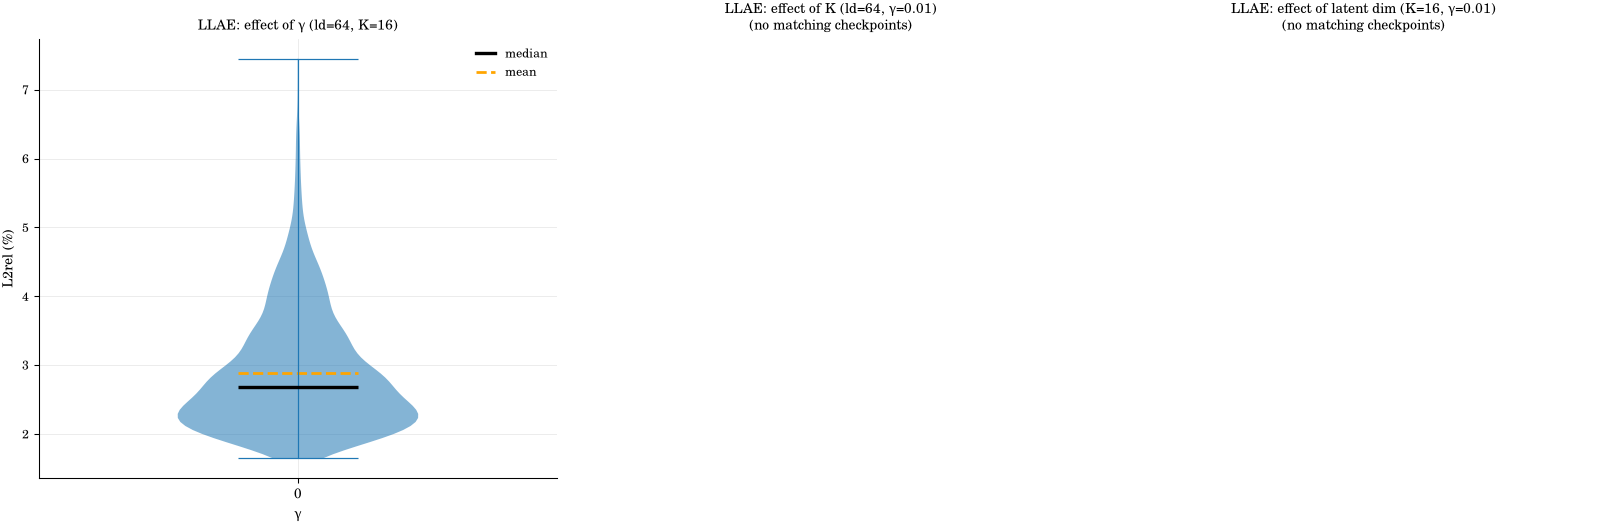

  ↳ article/images/optae_ablation_llae.pdf


PosixPath('/users/eleves-b/2023/keyvan.attarian/diffusion_ae/article/images/optae_ablation_llae.pdf')

In [14]:
rows_gamma = _select_rows('llae', 'gamma', {'ld': 64, 'K': 16})
rows_K     = _select_rows('llae', 'K',     {'ld': 64, 'gamma': 0.01})
rows_ld    = _select_rows('llae', 'ld',    {'K': 16,  'gamma': 0.01})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
_plot_family(axes[0], rows_gamma, 'gamma', 'γ',               'LLAE: effect of γ (ld=64, K=16)')
_plot_family(axes[1], rows_K,     'K',     'K',               'LLAE: effect of K (ld=64, γ=0.01)')
_plot_family(axes[2], rows_ld,    'ld',    'latent dim (ld)', 'LLAE: effect of latent dim (K=16, γ=0.01)')

fig.suptitle('LLAE — L2rel distributions (test set)', fontweight='bold')
fig.tight_layout()
plt.show()
figstyle.save("ablation_llae")


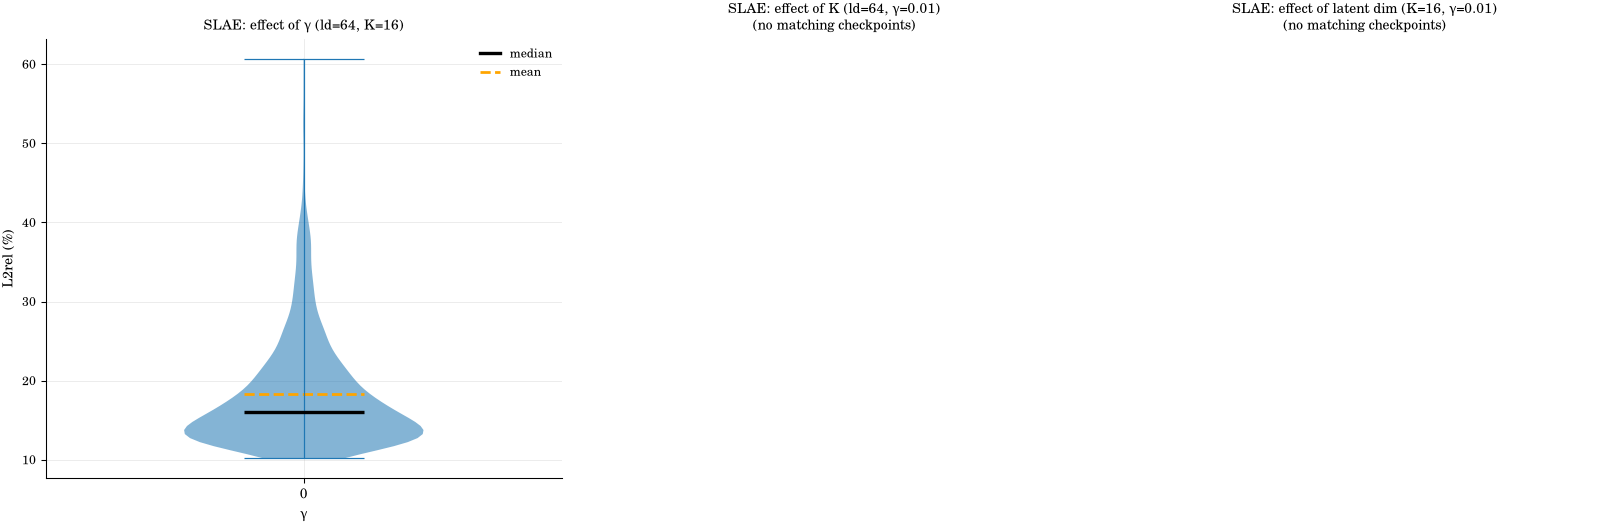

  ↳ article/images/optae_ablation_slae.pdf


PosixPath('/users/eleves-b/2023/keyvan.attarian/diffusion_ae/article/images/optae_ablation_slae.pdf')

In [15]:
rows_gamma_s = _select_rows('slae', 'gamma', {'ld': 64, 'K': 16})
rows_K_s     = _select_rows('slae', 'K',     {'ld': 64, 'gamma': 0.01})
rows_ld_s    = _select_rows('slae', 'ld',    {'K': 16,  'gamma': 0.01})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
_plot_family(axes[0], rows_gamma_s, 'gamma', 'γ',               'SLAE: effect of γ (ld=64, K=16)')
_plot_family(axes[1], rows_K_s,     'K',     'K',               'SLAE: effect of K (ld=64, γ=0.01)')
_plot_family(axes[2], rows_ld_s,    'ld',    'latent dim (ld)', 'SLAE: effect of latent dim (K=16, γ=0.01)')

fig.suptitle('SLAE — L2rel distributions (test set)', fontweight='bold')
fig.tight_layout()
plt.show()
figstyle.save("ablation_slae")


## 8. Inference latency benchmark

Per-sample AE reconstruction latency at `bs=1` (10 warm-up / 50 timed runs), measuring the
full round-trip `U(t) → encode → [Laplace / inverse] → decode → Û(t)` on one simulation.

In [16]:
import benchmark   # methodologie commune a tous les notebooks

# Single benchmark sample (bs=1), reused for every checkpoint
U_bench = load_u(test_idx[0])[None]        # (1, Nt, N, N)
print(f'Benchmark sample shape: {U_bench.shape}  |  device: {device}\n')

bench = {}   # name → dict(lat_med, lat_std)

for ckpt_path in ckpt_paths:
    name = os.path.splitext(os.path.basename(ckpt_path))[0]
    try:
        pipe = InferencePipelineAE.from_checkpoint(ckpt_path, device=device)

        def lat_fn():
            with torch.no_grad():
                pipe.reconstruct(U_bench)

        bench[name] = benchmark.measure(lat_fn, device, name=name)

        pipe.model.cpu(); del pipe
        if device == 'cuda':
            torch.cuda.empty_cache()
        gc.collect()

    except Exception as e:
        print(f'{name}  ERROR: {e}')

print('\nDone.')

Benchmark sample shape: (1, 150, 128, 128)  |  device: cuda



llae_ld64_K16_g0.0_ll                         lat=   33.5±  1.4 ms  flops=  54.2 G  mem=   556 MB  E=3465.0 mJ


llae_ld64_K32_g0.0_ll                         lat=   34.0±  1.8 ms  flops=  54.2 G  mem=   556 MB  E=3878.1 mJ


llae_ld64_K8_g0.0_ll                          lat=   33.3±  1.7 ms  flops=  54.2 G  mem=   556 MB  E=3733.5 mJ


slae_ld64_K16_g0.0_ol                         lat=   21.3±  1.3 ms  flops=  31.1 G  mem=   158 MB  E=2585.9 mJ


slae_ld64_K32_g0.0_ol                         lat=   28.8±  1.4 ms  flops=  62.2 G  mem=   280 MB  E=3353.7 mJ


slae_ld64_K8_g0.0_ol                          lat=   19.5±  1.3 ms  flops=  15.5 G  mem=   121 MB  E=2107.1 mJ

Done.


checkpoint                                       lat (ms)       ±   FLOPs (G)   mem (MB)    E (mJ)
--------------------------------------------------------------------------------------------------
SLAE  d=64, K=8, γ=0                                 19.5     1.3        15.5        121    2107.1
SLAE  d=64, K=16, γ=0                                21.3     1.3        31.1        158    2585.9
SLAE  d=64, K=32, γ=0                                28.8     1.4        62.2        280    3353.7
LLAE  d=64, K=8, γ=0                                 33.3     1.7        54.2        556    3733.5
LLAE  d=64, K=16, γ=0                                33.5     1.4        54.2        556    3465.0
LLAE  d=64, K=32, γ=0                                34.0     1.8        54.2        556    3878.1


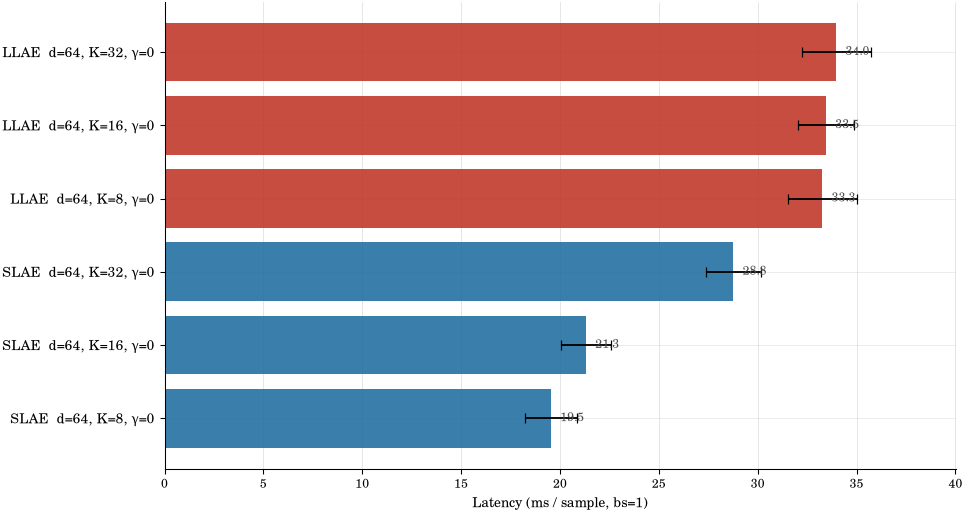

  ↳ article/images/optae_bench_latency.pdf


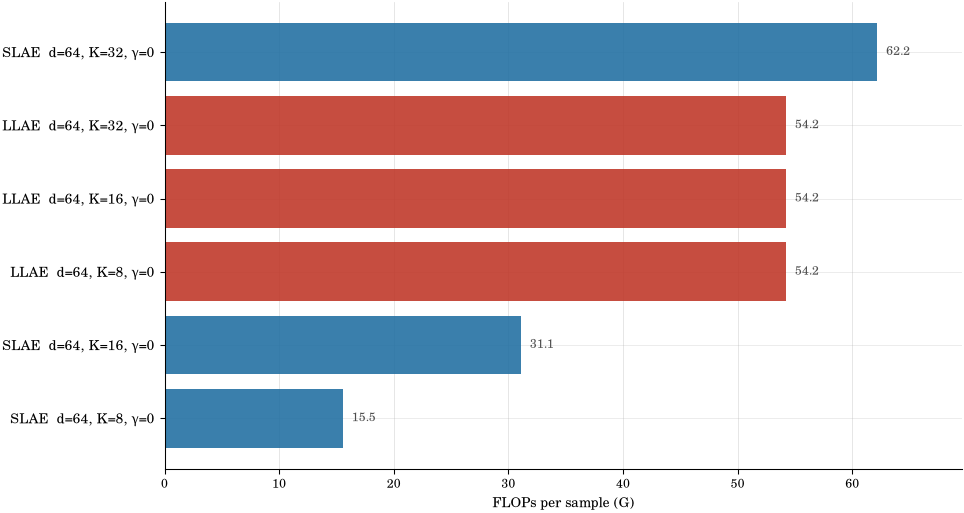

  ↳ article/images/optae_bench_flops.pdf


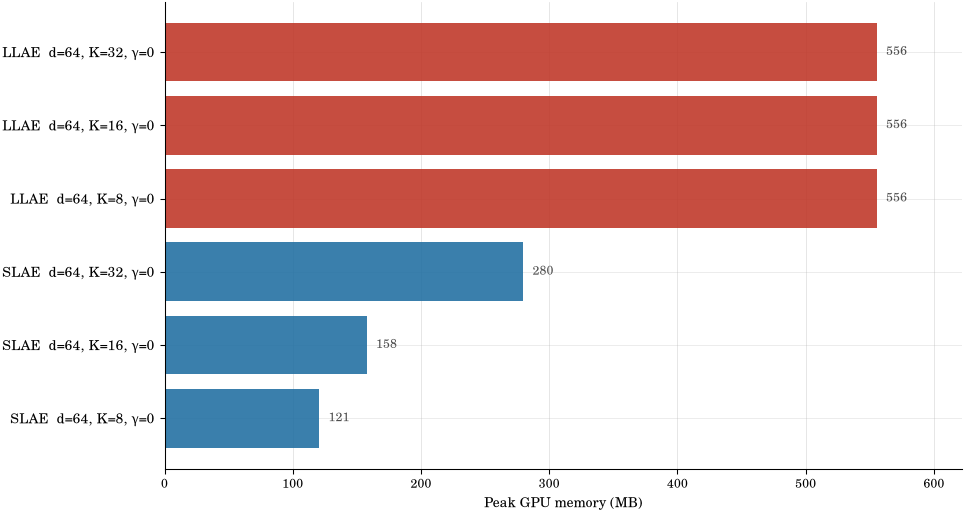

  ↳ article/images/optae_bench_memory.pdf


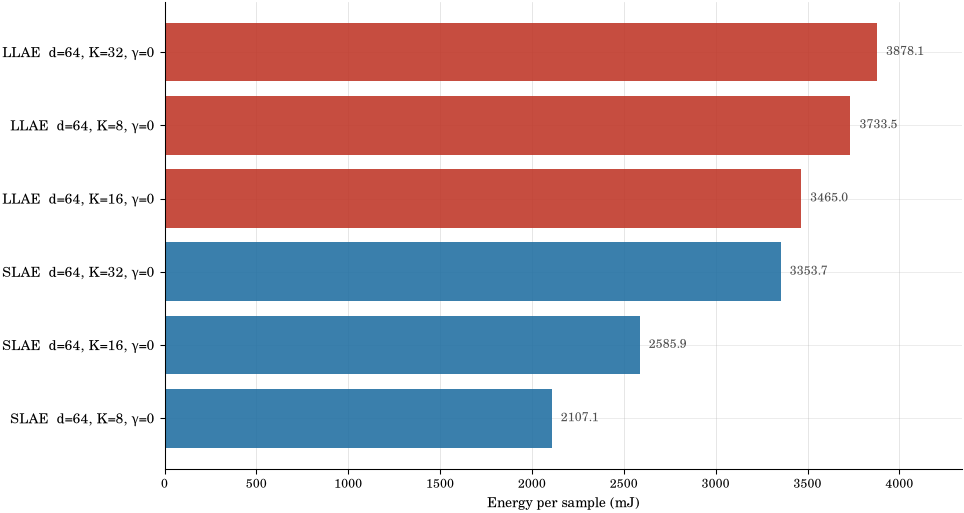

  ↳ article/images/optae_bench_energy.pdf


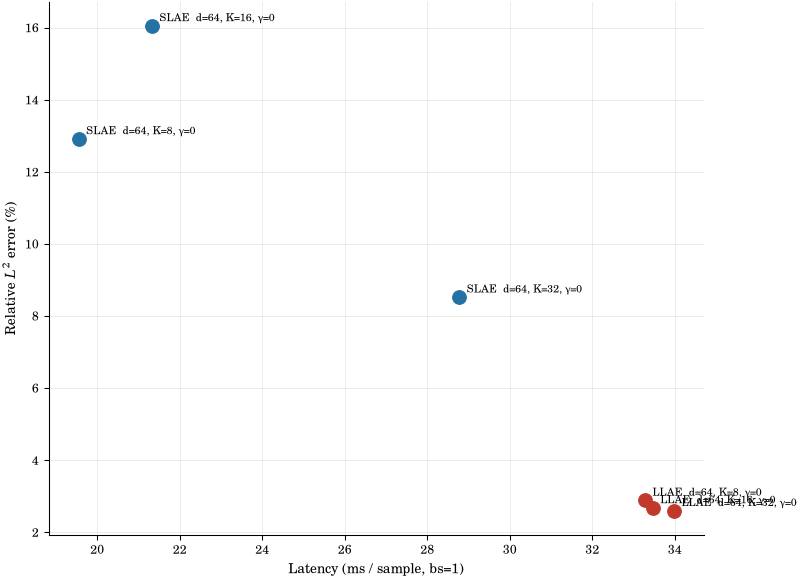

  ↳ article/images/optae_cost_latency.pdf


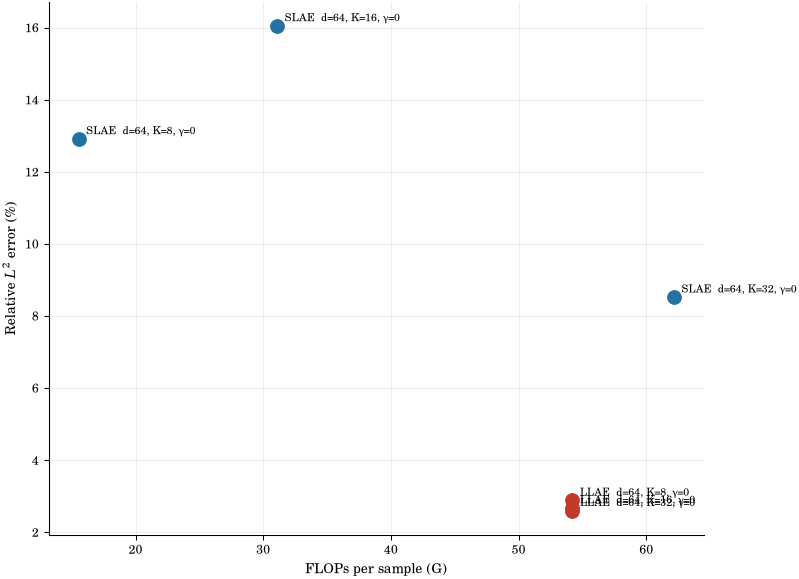

  ↳ article/images/optae_cost_flops.pdf


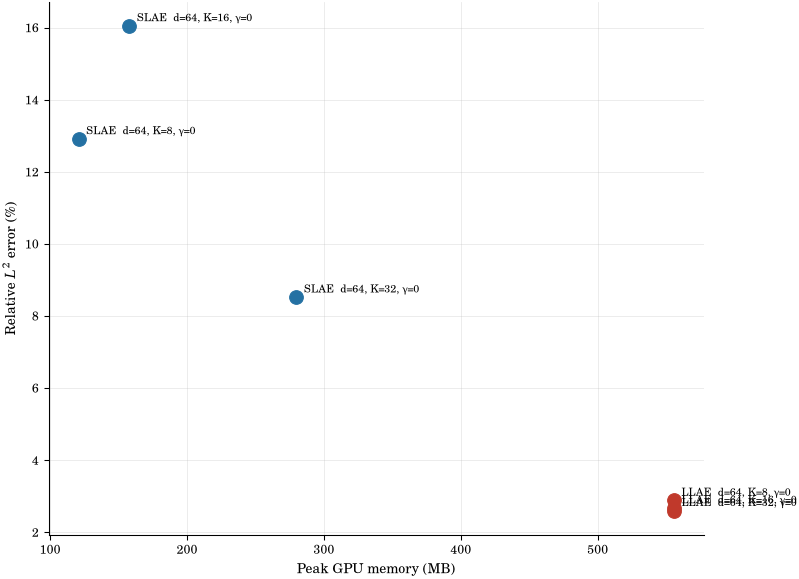

  ↳ article/images/optae_cost_memory.pdf


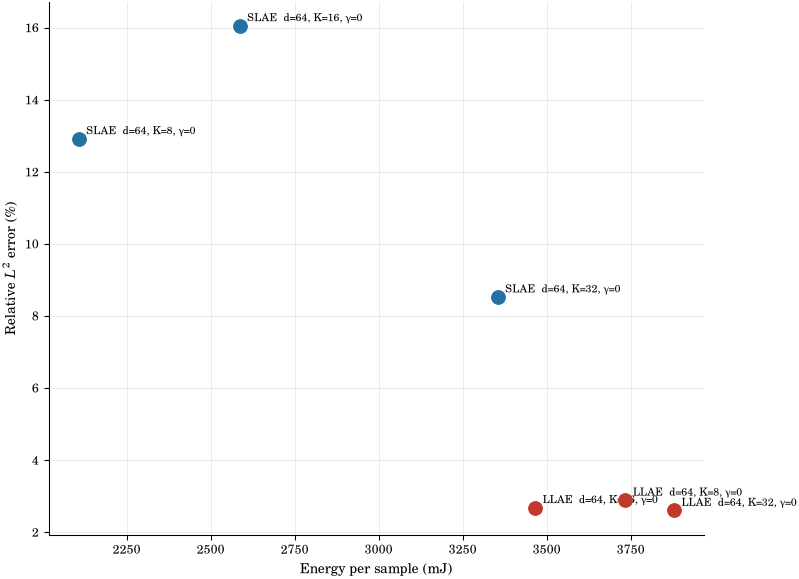

  ↳ article/images/optae_cost_energy.pdf


['cost_latency', 'cost_flops', 'cost_memory', 'cost_energy']

In [17]:
# One figure per metric, plus the matching accuracy/cost scatter.
def _bench_color(n):
    return colors['llae' if n.startswith('llae') else 'slae']

benchmark.table(bench, label_of=_pretty_name)

benchmark.figures(bench, label_of=_pretty_name, color_of=_bench_color, device=device)

_acc = {n: float(np.median(results[n])) for n in results if n in bench}
benchmark.scatter(bench, _acc, label_of=_pretty_name, color_of=_bench_color,
                  device=device, ylabel=figstyle.LABELS['l2rel'])
